# Societe Generale: Cross Asset Research - Trend Following

Trend-following and mean-reversion strategies on credit indices. 

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
trend_renamer_ = {
    'medium_term_market' : "Medium Trend", 
    'short_term_market'  : "Short Trend",
    "price"              : "CDS Index",
    "spread"             : "CDS Spread"}

renamer = {**trend_renamer_}

In [24]:
writeup_path = os.getcwd()
res_path     = os.path.abspath(os.path.join(writeup_path, ".."))
repo_path    = os.path.abspath(os.path.join(res_path, ".."))
data_path    = os.path.join(repo_path, "data")
sig_path     = os.path.join(data_path, "Signals")
cred_path    = os.path.join(data_path, "CreditData")

## Get and Read Data

In [19]:
path      = os.path.join(cred_path, r"PrepCDS.parquet")
df_longer = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .melt(id_vars = ["date", "SecurityGroup"])
    .dropna())

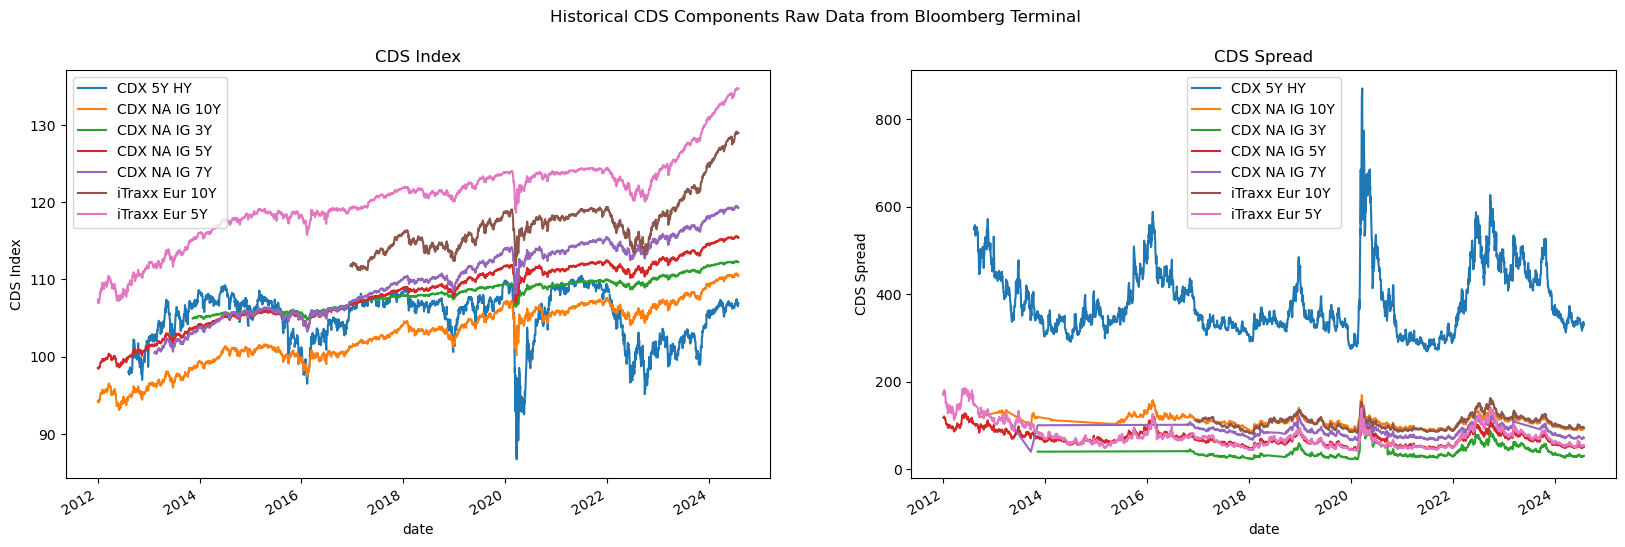

In [23]:
variables = df_longer.variable.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(variables), figsize = (20,6))

for variable, ax in zip(variables, axes.flatten()): 

    (df_longer
        .loc[lambda x: x.variable == variable]
        .rename(columns = {"SecurityGroup": ""})
        .pivot(index = "date", columns = "", values = "value")
        .plot(
            ax     = ax,
            title  = renamer[variable],
            ylabel = renamer[variable]))

fig.suptitle("Historical CDS Components Raw Data from Bloomberg Terminal")
plt.show()

# Kalman Filter Trend Following

In [37]:
path     = os.path.join(sig_path, r"SocGenCreditGenericKalman.parquet")
df_signal = (pd
    .read_parquet(path = path, engine = "pyarrow")
    [["SecurityGroup", "date", "short_term_market", "short_term_residual", "medium_term_market", "medium_term_residual"]]
    .melt(id_vars = ["date", "SecurityGroup"])
    .dropna()
    .set_index("date")
    .groupby(["SecurityGroup", "variable"])
    .apply(lambda x: x.value.shift())
    .reset_index())

The use the Kalman Filter to extra the smoothed component from the KF and then use the difference between the smoothed value and the actual as the signal for the mean reversion. Then they run a regression between the signal and time

In [40]:
path   = os.path.join(cred_path,r"PrepCDS.parquet")
df_rtn = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .drop(columns = ["spread"])
    .dropna()
    .set_index("date")
    .groupby("SecurityGroup")
    .apply(lambda x: x.sort_index().price.pct_change())
    .to_frame(name = "idx_rtn")
    .reset_index())

In [41]:
df_combined = (df_rtn
    .merge(right = df_signal, how = "inner", on = ["date", "SecurityGroup"])
    .assign(signal_rtn = lambda x: np.sign(x.value) * x.idx_rtn))

In [42]:
df_trend = (df_combined
    .assign(
        name   = lambda x: x.SecurityGroup + "-" + x.variable,
        ending = lambda x: x.variable.str.split("_").str[-1])
    .loc[lambda x: x.ending == "market"])

In [43]:
df_trend_vol = (df_trend
    .pivot(index = "date", columns = "name", values = "signal_rtn")
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x))
    .reset_index()
    .melt(id_vars = "date")
    .dropna()
    .assign(
        SecurityGroup = lambda x: x.name.str.split("-").str[0],
        variable      = lambda x: x.name.str.split("-").str[1])
    .drop(columns = ["name"]))

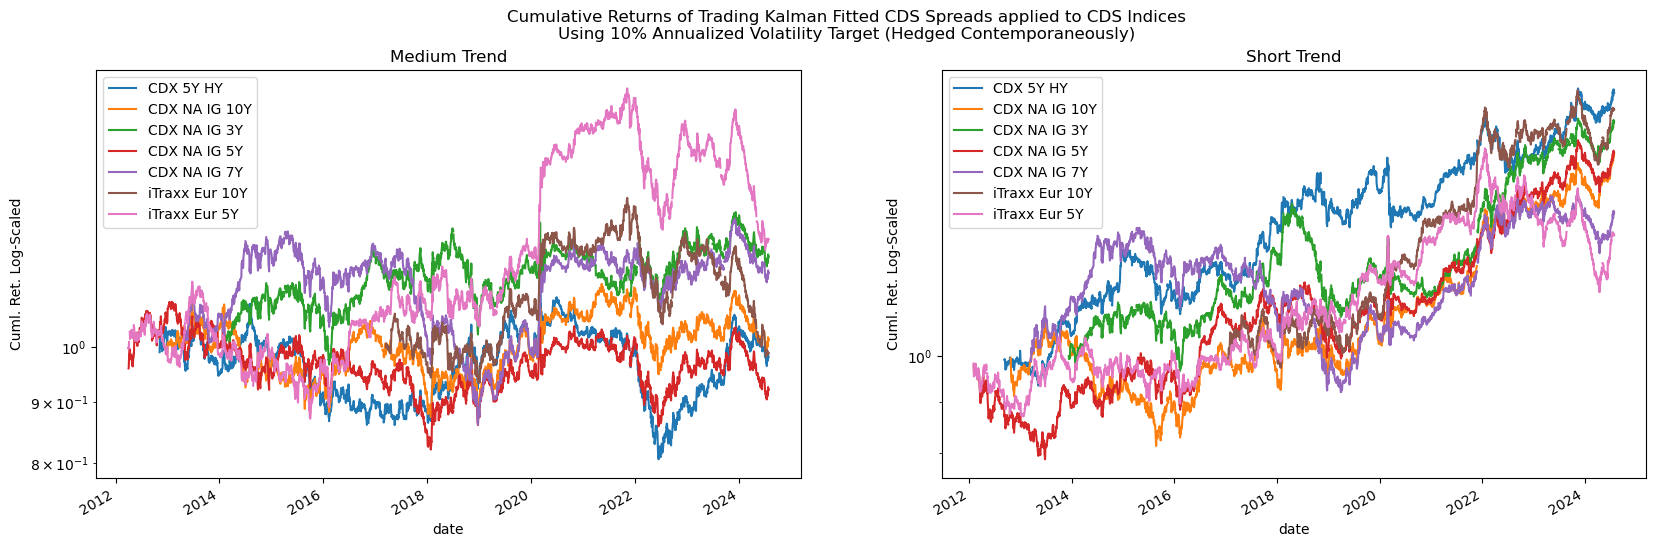

In [44]:
signals   = df_trend_vol.variable.drop_duplicates().to_list()
fig, axes = plt.subplots(ncols = len(signals), figsize = (20,6))

for signal, ax in zip(signals, axes.flatten()):

    (df_trend_vol
        .loc[lambda x: x.variable == signal]
        .rename(columns = {"SecurityGroup": ""})
        .pivot(index = "date", columns = "", values = "value")
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = renamer[signal]))

fig.suptitle("Cumulative Returns of Trading Kalman Fitted CDS Spreads applied to CDS Indices\nUsing 10% Annualized Volatility Target (Hedged Contemporaneously)")
plt.show()

In [11]:
df_trend_sharpe = (df_trend_vol
    [["variable", "SecurityGroup", "value"]]
    .replace(renamer)
    .groupby(["SecurityGroup", "variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .rename(columns = {
        "variable"     : "signal",
        "SecurityGroup": ""})
    .pivot(index = "signal", columns = "", values = "value"))

display(df_trend_sharpe)

,CDX 5Y HY,CDX NA IG 10Y,CDX NA IG 3Y,CDX NA IG 5Y,CDX NA IG 7Y,iTraxx Eur 10Y,iTraxx Eur 5Y
signal,,,,,,,
Medium Trend,0.031398,0.062205,0.224493,-0.019717,0.182243,0.033814,0.224353
Short Trend,0.591638,0.460745,0.581803,0.438283,0.349022,0.810390,0.278977


They apply an optimization that picks the signal that has best 1 month perfomance in sharpe. In this case the sharpe is calculated on the volatility targeted returns. 

In [12]:
window = 30

df_opt_signal = (df_trend_vol
    .set_index("date")
    .groupby(["SecurityGroup", "variable"])
    .apply(lambda x: x.sort_index().value.rolling(window = window).mean() / x.sort_index().value.rolling(window = window).std())
    .reset_index()
    .pivot(index = ["date", "SecurityGroup"], columns = "variable", values = "value")
    .assign(max_val = lambda x: x.max(axis = 1))
    .reset_index()
    .melt(id_vars = ["date", "SecurityGroup", "max_val"])
    .loc[lambda x: x.max_val == x.value]
    .dropna()
    .drop(columns = ["max_val"])
    .set_index("date")
    .groupby("SecurityGroup")
    .apply(lambda x: x.shift())
    .reset_index())

In [13]:
df_selector = (df_trend_vol
    .set_index("date")
    .groupby(["SecurityGroup", "variable"])
    .apply(lambda x: x.sort_index().value.rolling(window = window).mean() / x.sort_index().value.rolling(window = window).std())
    .reset_index()
    .pivot(index = ["date", "SecurityGroup"], columns = "variable", values = "value")
    .assign(max_val = lambda x: x.max(axis = 1))
    .reset_index()
    .melt(id_vars = ["date", "SecurityGroup", "max_val"])
    .loc[lambda x: x.max_val == x.value]
    .dropna()
    .drop(columns = ["max_val", "value"]))

In [14]:
df_opt = (df_signal
    .merge(right = df_selector, how = "inner", on = ["date", "SecurityGroup", "variable"])
    .merge(right = df_rtn     , how = "inner", on = ["date", "SecurityGroup"])
    .assign(signal_rtn = lambda x: np.sign(x.value) * x.idx_rtn))

In [15]:
df_vol_opt = (df_opt
    .set_index("date")
    [["SecurityGroup", "signal_rtn"]]
    .groupby("SecurityGroup")
    .apply(lambda x: x.sort_index().signal_rtn * (0.1 / (x.sort_index().signal_rtn.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .reset_index())

In [16]:
df_opt_sharpe = (df_vol_opt
    .drop(columns = ["date"])
    .groupby("SecurityGroup")
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index())

In [17]:
(df_trend_sharpe
    .reset_index()
    .melt(id_vars = "signal")
    .rename(columns = {"": "SecurityGroup"})
    .merge(right = df_opt_sharpe, how = "inner", on = ["SecurityGroup"])
    .rename(columns = {"signal": ""})
    .pivot(index = ["SecurityGroup", "signal_rtn"], columns = "", values = "value")
    .reset_index()
    .rename(columns = {"signal_rtn": "Adapt Signal"})
    .set_index("SecurityGroup"))

,Adapt Signal,Medium Trend,Short Trend
SecurityGroup,,,
CDX 5Y HY,1.622535,0.031398,0.591638
CDX NA IG 10Y,1.368678,0.062205,0.460745
CDX NA IG 3Y,1.374007,0.224493,0.581803
CDX NA IG 5Y,1.584636,-0.019717,0.438283
CDX NA IG 7Y,1.285521,0.182243,0.349022
iTraxx Eur 10Y,1.783381,0.033814,0.810390
iTraxx Eur 5Y,1.637412,0.224353,0.278977


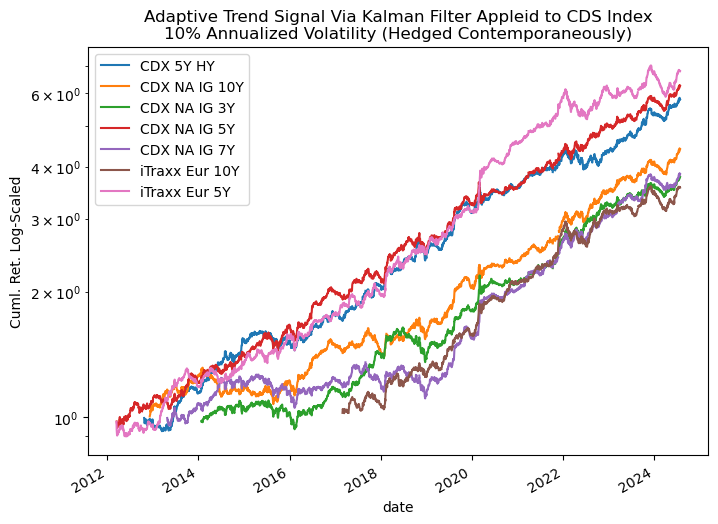

In [29]:
(df_vol_opt
    .rename(columns = {"SecurityGroup": ""})
    .pivot(index = "date", columns = "", values = "signal_rtn")
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        figsize = (8,6),
        ylabel  = "Cuml. Ret. Log-Scaled",
        logy    = True,
        title   = "Adaptive Trend Signal Via Kalman Filter Appleid to CDS Index\n10% Annualized Volatility (Hedged Contemporaneously)"))

plt.show()

In [46]:
(df_trend_vol
    .pivot(index = ["date", "SecurityGroup"], columns = "variable", values = "value")
    .reset_index()
    .merge(right = df_vol_opt, how = "inner", on = ["date", "SecurityGroup"])
    .melt(id_vars = ["date", "SecurityGroup", "signal_rtn"])
    .dropna()
    .drop(columns = ["date"])
    .groupby(["SecurityGroup", "variable"])
    .agg("corr")
    .loc[lambda x: x.value != 1]
    .reset_index()
    .rename(columns = {"variable": ""})
    .pivot(index = ["SecurityGroup"], columns = "", values = "value")
    .rename(columns = renamer))

,Medium Trend,Short Trend
SecurityGroup,,
CDX 5Y HY,0.671659,0.674693
CDX NA IG 10Y,0.699627,0.798936
CDX NA IG 3Y,0.708978,0.803734
CDX NA IG 5Y,0.635110,0.688414
CDX NA IG 7Y,0.779986,0.799088
iTraxx Eur 10Y,0.669546,0.772785
iTraxx Eur 5Y,0.702659,0.643520
